**BEST_OF OPTIONS**

In [8]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

QUESTION 1 et QUESTION 2 - CF. le pdf de Héléna

QUESTION 3 : 

In [ ]:
# Paramètres pour les simulations 

T = 1.5           
r = 0.02          
K = 1.0           
rho = 0.3         
S0 = [1.0, 1.0, 1.0]      
sigma = [0.3, 0.3, 0.3] 

N=10000

In [10]:

def normal_standard(d, N) : 
    """
    Génère une matrice (d, N) de variables normales standard
    """

    U = npr.random((d,N))
    V = npr.random((d,N))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

Le but de la question 3 est juste de générer un vecteur gaussien $$ W(T) := (W_1(T), W_2(T), W_3(T)) $$ de matrice de corrélation $\Gamma = (\text{Cov}(W_i(T), W_j(T))/{s_i s_j})_{ij}$, avec $s_i := \sqrt{\text{Var}(W_i(T))} = \sqrt{T}$ car m-b-s.  

Ainsi sa matrice de covariation $\Sigma = T \, \Gamma$. 

Nous utiliserons Cholesky : $$ \Gamma = A A^{\top} $$ pour $A$ triangulaire inférieure. Et, nous avons donc  $$ W(T) \underset{loi}{ = } \sqrt{T} \, A \, \mathcal{N}(0, I_3) \, . $$

In [11]:
def simulate_WT (N, t, rho) :
    """
    Génère le vecteur gaussien (W_1(T), W_2(T), W_3(T)), de matrice de corrélation Gamma. 
    """
    G = normal_standard(3, N)

    Gamma = [[1, rho, rho],
             [rho, 1, rho],
             [rho, rho, 1]]
    
    A = np.linalg.cholesky(Gamma)

    WT = np.sqrt(T) * A @ G

    return WT
    
    

Text(0.5, 0, 'W3(T)')

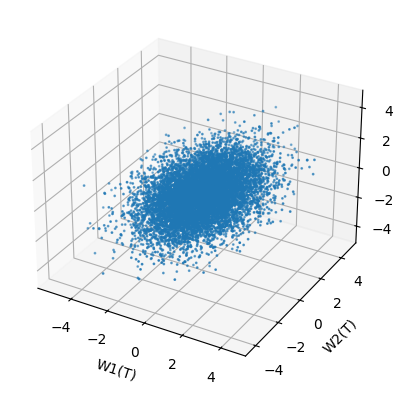

In [ ]:
# Visualisation : 

WT = simulate_WT(N, T, rho)

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(WT[0], WT[1], WT[2], s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')

QUESTION 3 - SUITE

On estime par Monte-Carlo classique (i.e. LGN) $$ P^1 := e^{-rT} \mathbf{E} \left[ \max_i S_T^i \right] - K e^{-rT} $$
où $$  S^i_t = \exp\left(\log( S^i_t)\right) = s^i_0\exp\left(\left(r - \dfrac{\sigma_i^2}{2}\right)t + \sigma_i W^i_t\right) \quad p.s. $$

In [ ]:
# mcc pour monte carlo classique
def mcc_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):
    
    S0_vec = np.array(S0)
    sigma_vec = np.array(sigma)
    
    Wt = simulate_WT(n, t, rho) # taille 3*n
    
    # Calcul de S(T) (matrice 3*n)
    # sigma_vec * Wt : calcule produit terme à terme. Mais les termes de W_t sont des lignes, qui simule W_i. 
    # et le + fait aussi la somme terme à terme. 
    
    ST = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) # taille 3*n
    
    # On prend le max pour chaque colonne (axis=0)
    max_ST = np.max(ST, axis=0) # taille 3*n
    
    # Prix estimé
    return np.exp(-r * t) * (np.mean(max_ST) - K)

mcc_P1(10000000)

np.float64(0.3003489023346395)

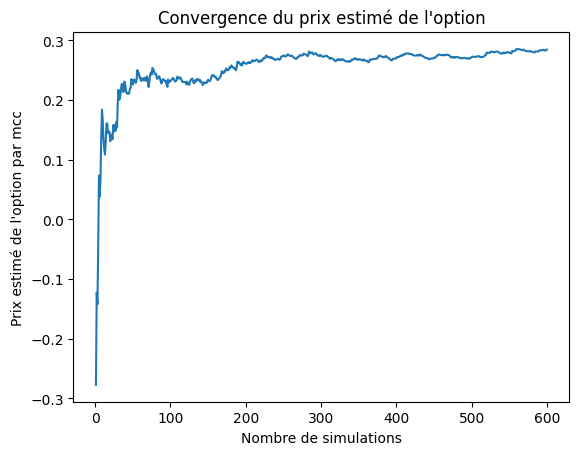

In [126]:
def visualise_mcc_P1 (Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :

    S0_vec = np.array(S0)
    sigma_vec = np.array(sigma)
    
    Wt = simulate_WT(Nmax, t, rho) 
    
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) 
    
    # On prend le max pour chaque colonne (axis=0)
    max_St = np.max(St, axis=0) 

    moyennes = np.cumsum(max_St) / np.arange(1, Nmax +1)

    prix_estimes = np.exp(-r * t) * (moyennes - K)
    
    plt.plot(np.arange(1, Nmax +1), prix_estimes)
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option par mcc')
    plt.title('Convergence du prix estimé de l\'option')
    

visualise_mcc_P1(600)
# =0.3

QUESTION 4 : 

In [119]:
# mca pour monte carlo antithétique

def mca_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):
    
    S0_vec = np.array(S0)
    sigma_vec = np.array(sigma)

    Wt = simulate_WT(n, t, rho)
    
    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)
    
    return np.exp(-r * t) * (np.mean(V) - K)

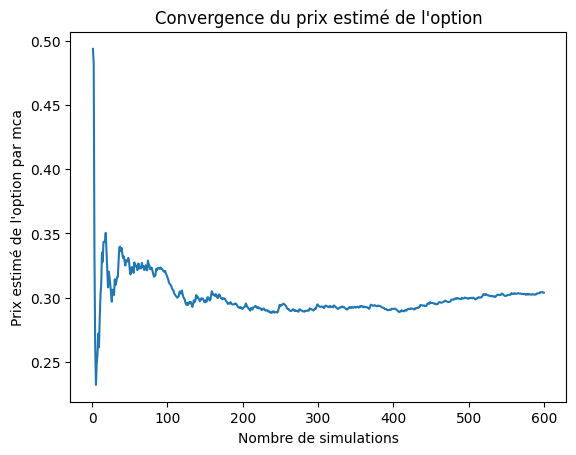

In [141]:
def visualise_mca_P1(Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :
    S0_vec = np.array(S0)
    sigma_vec = np.array(sigma)
    
    Wt = simulate_WT(Nmax, t, rho) 

    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)

    prix_estimes = np.exp(-r * t) * (moyennes - K)
    
    plt.plot(np.arange(1, Nmax +1), prix_estimes)
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option par mca')
    plt.title('Convergence du prix estimé de l\'option')

visualise_mca_P1(600)
    